In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing



In [10]:
#Dataset

df = pd.read_csv("HousingData.csv")
print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90    NaN  36.2  


In [11]:
df.shape

(506, 14)

In [12]:
df.describe

<bound method NDFrame.describe of         CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  \
0    0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296   
1    0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242   
2    0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242   
3    0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222   
4    0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222   
..       ...   ...    ...   ...    ...    ...   ...     ...  ...  ...   
501  0.06263   0.0  11.93   0.0  0.573  6.593  69.1  2.4786    1  273   
502  0.04527   0.0  11.93   0.0  0.573  6.120  76.7  2.2875    1  273   
503  0.06076   0.0  11.93   0.0  0.573  6.976  91.0  2.1675    1  273   
504  0.10959   0.0  11.93   0.0  0.573  6.794  89.3  2.3889    1  273   
505  0.04741   0.0  11.93   0.0  0.573  6.030   NaN  2.5050    1  273   

     PTRATIO       B  LSTAT  MEDV  
0       15.3  396.90   4.98  24.0  
1       17.8  396

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [20]:
# Feature corelation matrix

df.corr

<bound method DataFrame.corr of         CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  \
0    0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296   
1    0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242   
2    0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242   
3    0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222   
4    0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222   
..       ...   ...    ...   ...    ...    ...   ...     ...  ...  ...   
501  0.06263   0.0  11.93   0.0  0.573  6.593  69.1  2.4786    1  273   
502  0.04527   0.0  11.93   0.0  0.573  6.120  76.7  2.2875    1  273   
503  0.06076   0.0  11.93   0.0  0.573  6.976  91.0  2.1675    1  273   
504  0.10959   0.0  11.93   0.0  0.573  6.794  89.3  2.3889    1  273   
505  0.04741   0.0  11.93   0.0  0.573  6.030   NaN  2.5050    1  273   

     PTRATIO       B  LSTAT  MEDV  
0       15.3  396.90   4.98  24.0  
1       17.8  396.9

<Axes: >

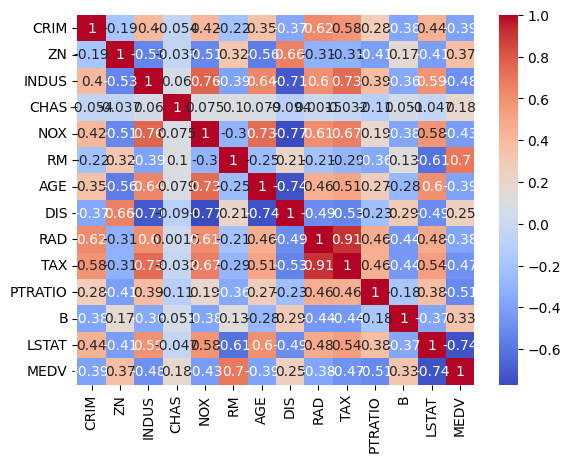

In [25]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

In [27]:
# Dataprocessing :

df.isnull().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [28]:
print(df.isnull().sum().sum())

120


In [29]:
print(df[df.isnull().any(axis=1)])

         CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  \
4     0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222   
6     0.08829  12.5   7.87   NaN  0.524  6.012  66.6  5.5605    5  311   
9     0.17004  12.5   7.87   NaN  0.524  6.004  85.9  6.5921    5  311   
14    0.63796   0.0   8.14   NaN  0.538  6.096  84.5  4.4619    4  307   
35    0.06417   0.0   5.96   0.0  0.499  5.933  68.2  3.3603    5  279   
..        ...   ...    ...   ...    ...    ...   ...     ...  ...  ...   
473   4.64689   0.0  18.10   0.0  0.614  6.980  67.6  2.5329   24  666   
479  14.33370   0.0  18.10   NaN  0.614  6.229  88.0  1.9512   24  666   
482   5.73116   0.0  18.10   NaN  0.532  7.061  77.0  3.4106   24  666   
501   0.06263   0.0  11.93   0.0  0.573  6.593  69.1  2.4786    1  273   
505   0.04741   0.0  11.93   0.0  0.573  6.030   NaN  2.5050    1  273   

     PTRATIO       B  LSTAT  MEDV  
4       18.7  396.90    NaN  36.2  
6       15.2  395.60  12.43  22.9  
9  

In [37]:
print("="*50)
print("Duplicate Rows")
print(df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

# Fill missing values
for col in df.columns:

    if df[col].dtype == "object":

        df[col].fillna(df[col].mode()[0], inplace=True)

    else:

        df[col].fillna(df[col].median(), inplace=True)

print("="*50)
print("Missing Values After Cleaning")
print(df.isnull().sum())

# Save Clean Dataset
df.to_csv("clean_housing.csv", index=False)

print("\nClean Dataset Saved Successfully")

Duplicate Rows
0
Missing Values After Cleaning
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Clean Dataset Saved Successfully


C:\Users\hada\AppData\Local\Temp\ipykernel_13224\1188400715.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\hada\AppData\Local\Temp\ipykernel_13224\1188400715.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [38]:
null_percentage = (df.isnull().sum() / len(df)) * 100

print(null_percentage)

CRIM       0.0
ZN         0.0
INDUS      0.0
CHAS       0.0
NOX        0.0
RM         0.0
AGE        0.0
DIS        0.0
RAD        0.0
TAX        0.0
PTRATIO    0.0
B          0.0
LSTAT      0.0
MEDV       0.0
dtype: float64


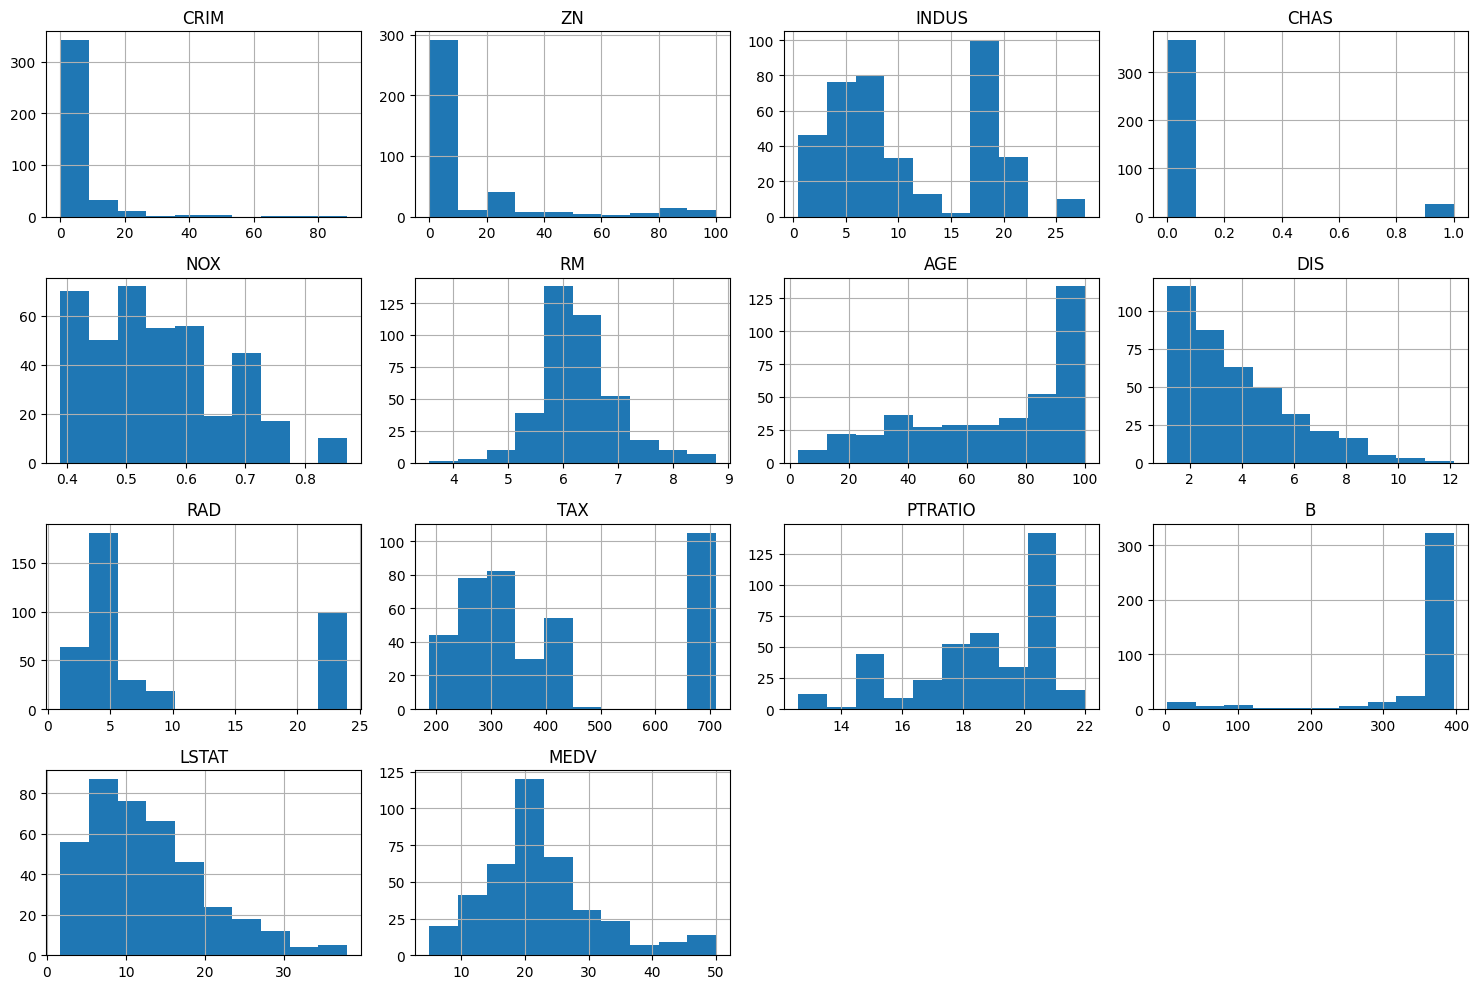

In [39]:
# Histogram

df.hist(figsize=(15,10))

plt.tight_layout()

plt.show()

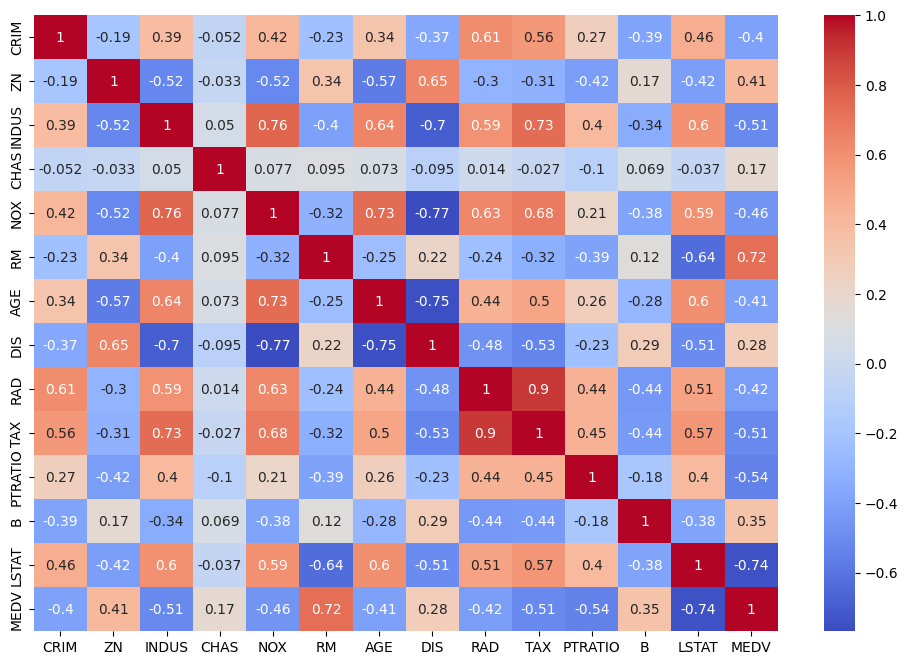

In [40]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

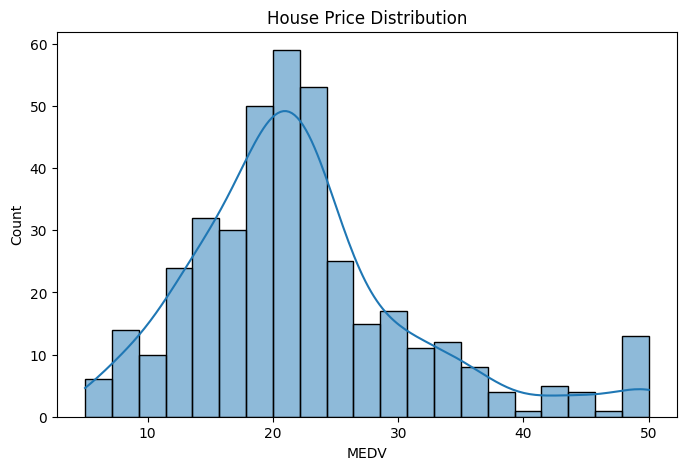

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(df["MEDV"], kde=True)

plt.title("House Price Distribution")

plt.show()

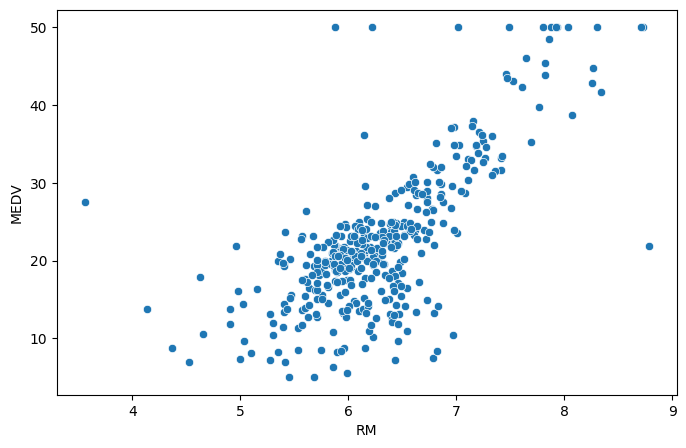

In [42]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["RM"],
    y=df["MEDV"]
)

plt.show()

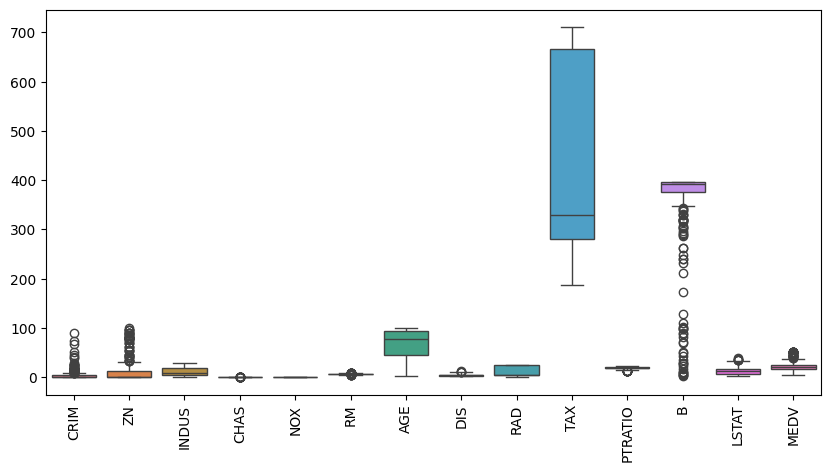

In [43]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.show()

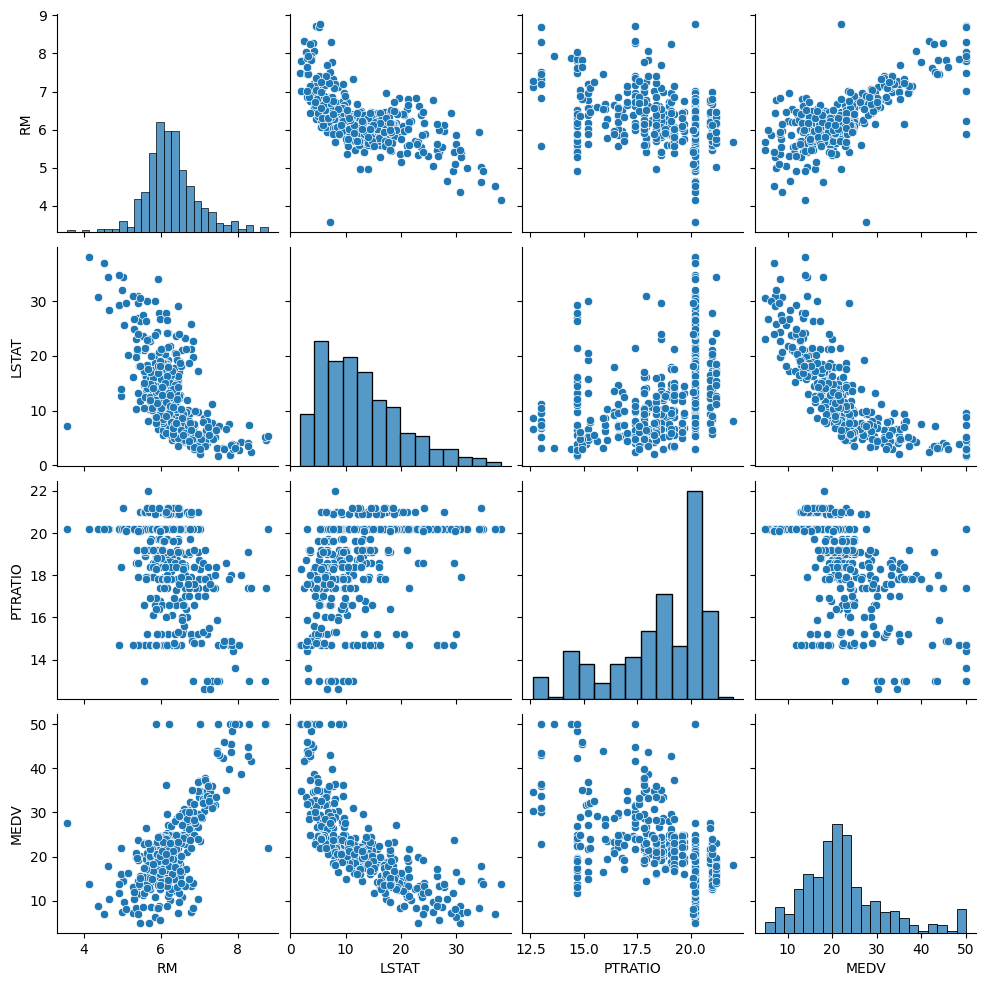

In [44]:
sns.pairplot(
    df[
        [
            "RM",
            "LSTAT",
            "PTRATIO",
            "MEDV"
        ]
    ]
)

plt.show()

In [51]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
X = df.drop("MEDV", axis=1)

y = df["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("\n========== Linear Regression ==========")

print("R2 Score :", r2_score(y_test, lr_pred))

print("MAE :", mean_absolute_error(y_test, lr_pred))

print("RMSE :", mean_squared_error(y_test, lr_pred) ** 0.5)


========== Linear Regression ==========
R2 Score : 0.627084994167318
MAE : 3.367983225154248
RMSE : 5.608390826694495


In [53]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("\n========== Random Forest ==========")

print("R2 Score :", r2_score(y_test, rf_pred))

print("MAE :", mean_absolute_error(y_test, rf_pred))

print("RMSE :", mean_squared_error(y_test, rf_pred) ** 0.5)


========== Random Forest ==========
R2 Score : 0.6655552616602765
MAE : 2.719588607594937
RMSE : 5.311235084555919


In [55]:
import joblib
joblib.dump(rf, "best_model.pkl")

print("\nBest Model Saved Successfully")


Best Model Saved Successfully


In [56]:
model = joblib.load("best_model.pkl")

df = pd.read_csv("clean_housing.csv")

sample = df.drop("MEDV", axis=1).iloc[[0]]

prediction = model.predict(sample)

print("Predicted Price :", prediction[0])

Predicted Price : 27.44450000000002
